# 학과 : 빅데이터응용학과
# 학번 : 20223059
# 이름 : 원태연


- **문제 풀이 전 반드시 아래 사항을 읽고 지침에 따라 제출하세요.**

1. 제출 파일명은 반드시 **`이름_학번.ipynb`** 형식으로 제출할 것  
   (예: `홍길동_202312345.ipynb`)
2. **코드 실행 오류가 있는 경우 해당 문항은 0점 처리**됩니다. (부분점수 없음)
3. **모든 셀을 실행한 후**, 결과가 잘 보이도록 저장하여 제출하세요. (코드 실행 여부 확인합니다)



**문제1**


# 데이터 설명
심혈관 질환 연구에서 수집한 데이터이다. 해당 데이터는 환자의 정보를 제공하며 13개의 열을 포함하고 있다. 우리의 목표는 적절한 알고리즘을 사용하여 Target 변수를 질병/정상으로 분류하는 것이다.

변수 설명

- age: 나이 (in years)
- sex: 성별 (1 = male; 0 = female)
- cp: 가슴 통증 유형 (chest pain type, 값: 0,1,2,3)
- trestbps: 병원에 입원했을 때의 안정 시 혈압 (mm Hg)
- chol: 혈중 콜레스테롤 수치 (mg/dl)
- fps: 공복혈당 > 120 mg/dl 여부 (1 = true; 0 = false)
- restech: 안정 시 심전도 결과 (값: 0,1,2)
- thalach: 운동 중 도달한 최대 심박수
- exang: 운동 유발 협심증 여부 (1 = yes; 0 = no)
- oldpeak: 운동에 의해 유도된 ST 감소 (안정 시 대비)
- slope: ST segment의 기울기 유형 (값: 0,1,2)
- ca: 혈관 조영술로 관찰된 주요 혈관의 수 (값: 0,1,2,3,4)
- thal: 심장 질환 유형 (0 = normal; 1 = fixed defect; 2 = reversible defect)
- target: 심장병 위험 여부 (0 = 위험 낮음; 1 = 위험 높음)

**데이터 로드**

다음 코드를 그대로 실행하여 데이터를 불러온 후 문제를 풀이하세요:

In [1]:
!gdown --id 1ZPAsKns0oek9Ag3NecivleVGvGTaNBmA

/usr/local/lib/python3.11/dist-packages/gdown/__main__.py:140: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From: https://drive.google.com/uc?id=1ZPAsKns0oek9Ag3NecivleVGvGTaNBmA
To: /content/data3.csv
100% 37.9k/37.9k [00:00<00:00, 56.0MB/s]


In [2]:
import pandas as pd
data = pd.read_csv("data3.csv")
data

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52.0,1,0,125,212.0,0,1,168.0,0,1.0,2,2,3,0
1,53.0,1,0,140,203.0,1,0,155.0,1,3.1,0,0,3,0
2,70.0,1,0,145,174.0,0,1,125.0,1,2.6,0,0,3,0
3,61.0,1,0,148,203.0,0,1,161.0,0,0.0,2,1,3,0
4,62.0,0,0,138,294.0,1,1,106.0,0,1.9,1,3,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1020,59.0,1,1,140,221.0,0,1,164.0,1,0.0,2,0,2,1
1021,60.0,1,0,125,258.0,0,0,141.0,1,2.8,1,1,3,0
1022,47.0,1,0,110,275.0,0,0,118.0,1,1.0,1,1,2,0
1023,50.0,0,0,110,254.0,0,0,159.0,0,0.0,2,0,2,1


# Q1. 다음 조건에 따라 결측치를 탐색하시오.
1. 데이터프레임 data에서 하나 이상의 결측치가 존재하는 변수(column) 를 모두 찾으시오.
2. 각 변수별로 결측치가 몇 개인지 출력하시오.

1. age,chol,thalach,oldpeak
2.age21개, chol18개, thalach6개, oldpeak45개

In [8]:
a=data.isna().sum()
a[a>0]

,0
age,21
chol,18
thalach,6
oldpeak,45


# Q2. 다음 조건에 따라 `age` 변수의 결측치를 처리하시오.
1. 먼저, 원본 데이터프레임 data를 복사하여 data1이라는 새로운 데이터프레임을 생성하시오. (원본 데이터 손상 방지 목적)
2. data1에서 `target` 값이 1인 경우에는 해당 그룹의 `age` 평균으로, 0인 경우에는 해당 그룹의 `age` 평균으로 각각 결측치를 대체하시오.
3. 결측치 대체는 반드시 data1 데이터프레임을 직접 수정하는 방식으로 수행하시오.
4. data1의 `age` 변수에 남아 있는 결측치의 개수를 출력하시오.

In [4]:
data1=data.copy()

iftarget1=data1[data1['target']==1].age.mean()
iftarget0=data1[data1['target']==0].age.mean()
data1.loc[data1['target']==1,'age']=data1[data1['target']==1].age.fillna(value=iftarget1)
data1.loc[data1['target']==0,'age']=data1[data1['target']==0].age.fillna(value=iftarget0)
print(data1['age'].isna().sum())

0


# Q3. 앞에서 결측치를 대체한 데이터프레임 data1에서 `chol`를 기준으로 오름차순 정렬하시오.
- 정렬된 결과는 data_sorted라는 새로운 변수에 저장하시오.
- 정렬 결과의 상위 5개 행을 출력하시오.

In [5]:
data_sorted=data1.sort_values(by='chol',ascending=True)
data_sorted.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
101,57.0,1,2,150,126.0,1,1,173.0,0,0.2,2,1,3,1
336,57.0,1,2,150,126.0,1,1,173.0,0,0.2,2,1,3,1
475,57.0,1,2,150,126.0,1,1,173.0,0,0.2,2,1,3,1
32,57.0,1,0,130,131.0,0,1,115.0,1,1.2,1,1,3,0
882,57.0,1,0,130,131.0,0,1,115.0,1,1.2,1,1,3,0


# Q4. 데이터프레임 data1에는 여러 변수들이 포함되어 있으며, 그 중 일부는 범주형 변수로 처리하는 것이 적절합니다.

다음 조건에 따라 코드를 작성하시오.
- sex, cp, target 변수는 범주형(categorical) 변수로 처리하시오.
- 변환 후, 데이터프레임의 각 열의 데이터 타입 변화를 확인하시오.

In [6]:
data1['sex']=data1['sex'].astype('category')
data1['cp']=data1['cp'].astype('category')
data1['target']=data1['target'].astype('category')
print(data1.dtypes)

age          float64
sex         category
cp          category
trestbps       int64
chol         float64
fbs            int64
restecg        int64
thalach      float64
exang          int64
oldpeak      float64
slope          int64
ca             int64
thal           int64
target      category
dtype: object


# Q5. data1 데이터프레임에는 심장병 여부(target)와 가슴 통증 유형(cp)의 정보가 포함되어 있습니다.
다음 조건에 따라 가장 많은 사례 수를 보인 통증 유형을 찾으시오.
- target 값이 1인 경우만 고려하시오 (심장병 위험이 높은 경우).
- 이들 중 cp 값(가슴 통증 유형)별로 몇 건씩 존재하는지 계산하시오.
- 사례 수가 가장 많은 cp 값은 무엇인지 구하시오.


In [7]:
target1=data1[data1['target']==1]
cp=target1.groupby('cp').size()
maxcp=cp.idxmax()
print(cp)
print(maxcp)

cp
0    122
1    134
2    219
3     51
dtype: int64
2


<ipython-input-7-4007788396>:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cp=target1.groupby('cp').size()


**문제2**

**데이터 설명**
당신은 슈퍼마켓 주인입니다. 고객에 대한 기본적인 데이터를 가지고 있습니다 (Customer ID, age, gender, annual income and spending score).
Spending Score는 고객 행동 및 구매 데이터와 같은 정의된 매개 변수를 기준으로 고객에게 할당된 데이터입니다.
당신은 고객을 이해하고 고객 특성에 따라 마케팅을 하고자 합니다.

**데이터 로드**

다음 코드를 그대로 실행하여 데이터를 불러온 후 문제를 풀이하세요

In [12]:
!gdown --id 11pDt7StB5Plqxy-nxM2MeZDoIBr8A5lx

/usr/local/lib/python3.11/dist-packages/gdown/__main__.py:140: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From: https://drive.google.com/uc?id=11pDt7StB5Plqxy-nxM2MeZDoIBr8A5lx
To: /content/data1.csv
100% 3.97k/3.97k [00:00<00:00, 17.3MB/s]


In [13]:
import pandas as pd
data2 = pd.read_csv("data1.csv")
data2

,CustomerID,Gender,Age,Annual_Income,Spending_Score
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
...,...,...,...,...,...
195,196,Female,35,120,79
196,197,Female,45,126,28
197,198,Male,32,126,74
198,199,Male,32,137,18


# Q6. 고객 데이터를 담고 있는 data2 데이터프레임에는 다음 세 개의 연속형 변수(Age, Annual_Income, Spending_Score)가 포함되어 있습니다. 각 변수의 분포를 확인하기 위해 아래 조건에 맞춰 히스토그램을 각각 생성하시오.

1. matplotlib 라이브러리를 이용하여 시각화하시오.
2. 각 히스토그램 크기는 (8, 5)의 크기로 시각화할 것
2. 각 변수에 대해 bins는 15, 투명도는 0.5, edgecolor는 navy로 설정할 것
3. Age는 색상 "pink", Annual_Income은 "blue", Spending_Score는 "skyblue"로 시각화할 것
4. 아래 결과물 그림과 같이 라벨을 설정할 것
5. 각 히스토그램을 별도의 Figure로 생성할 것(코드 한 셀에 그래프 하나가 출력되도록 할 것)

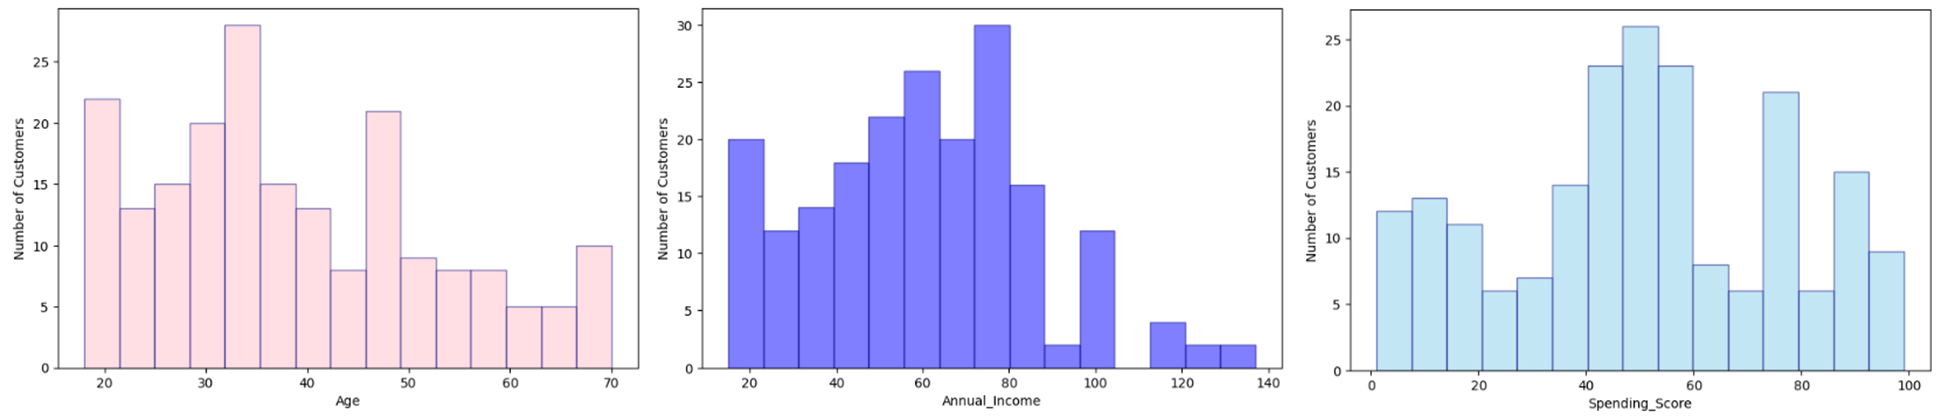

[]

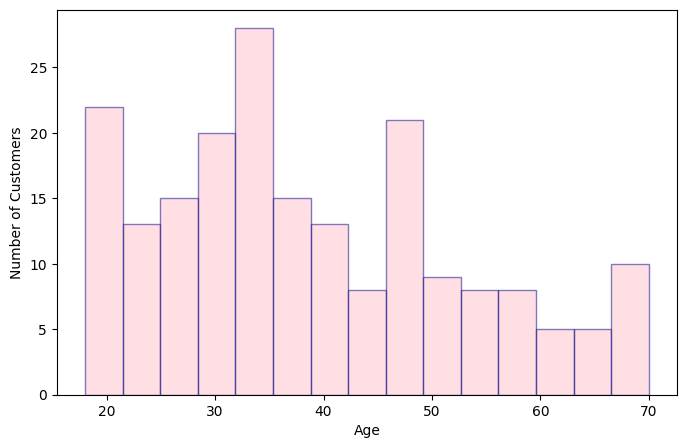

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.hist(data2['Age'],bins=15,color='pink',edgecolor='navy',alpha=0.5)
plt.xlabel('Age')
plt.ylabel('Number of Customers')
plt.plot()

[]

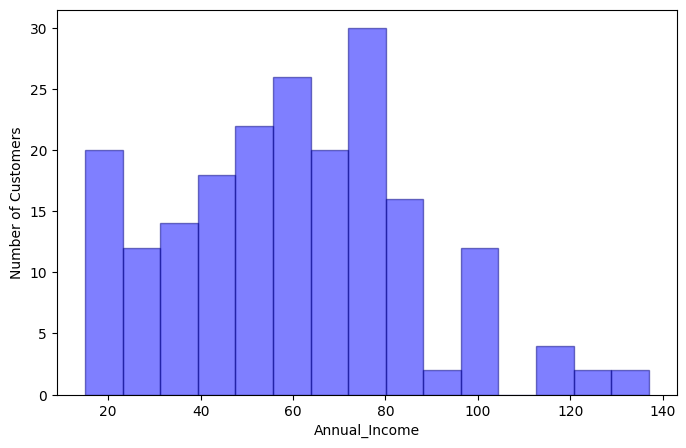

In [16]:
plt.figure(figsize=(8,5))
plt.hist(data2['Annual_Income'],bins=15,color='blue',edgecolor='navy',alpha=0.5)
plt.xlabel('Annual_Income')
plt.ylabel('Number of Customers')
plt.plot()

[]

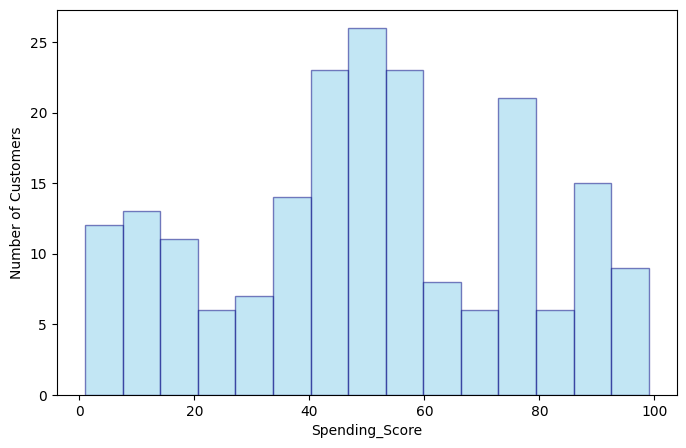

In [17]:
plt.figure(figsize=(8,5))
plt.hist(data2['Spending_Score'],bins=15,color='skyblue',edgecolor='navy',alpha=0.5)
plt.xlabel('Spending_Score')
plt.ylabel('Number of Customers')
plt.plot()

# Q7. 성별(Gender)에 따른 연령(Age) 분포를 시각화하시오.
seaborn 라이브러리를 활용하여 아래 조건에 맞는 두 개의 시각화를 1행 2열로 나란히 출력하시오.  
*※아래 예시 그림과 동일하게 출력되어야 함*
- 전체 그래프 크기는 **(15, 5)**로 설정할 것
- 스타일 테마는 "white"로 설정할 것  
- 첫 번째 그래프는 히스토그램으로 그리되,
    - 그 위에 밀도추정선을 추가하시오
    - 또한 성별에 따라 색상이 다르게 표시되도록 설정하시오
- 두 번째 그래프는 바이올린 그림을 이용하여,
    - 연령 분포를 성별에 따라 시각화하시오.   




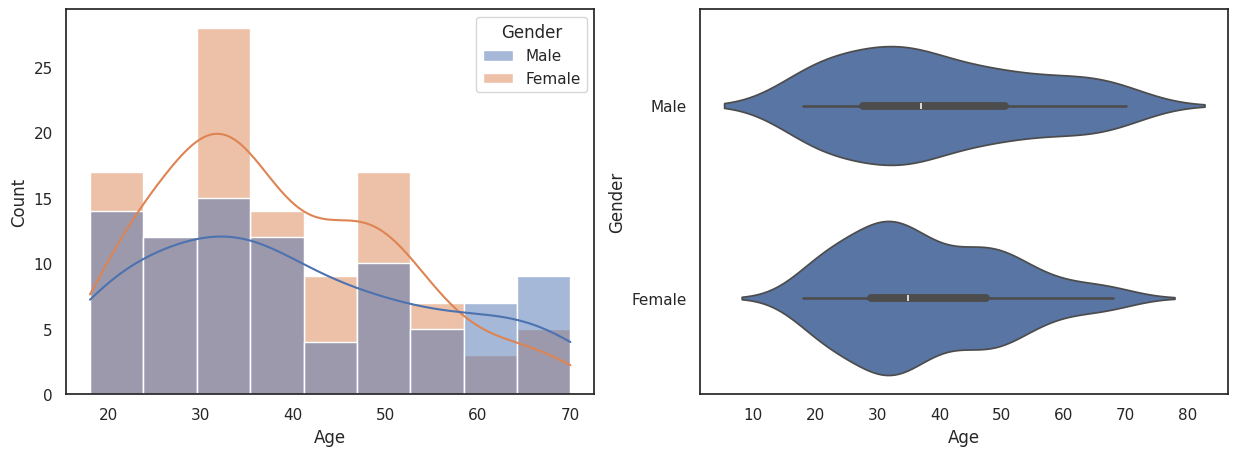

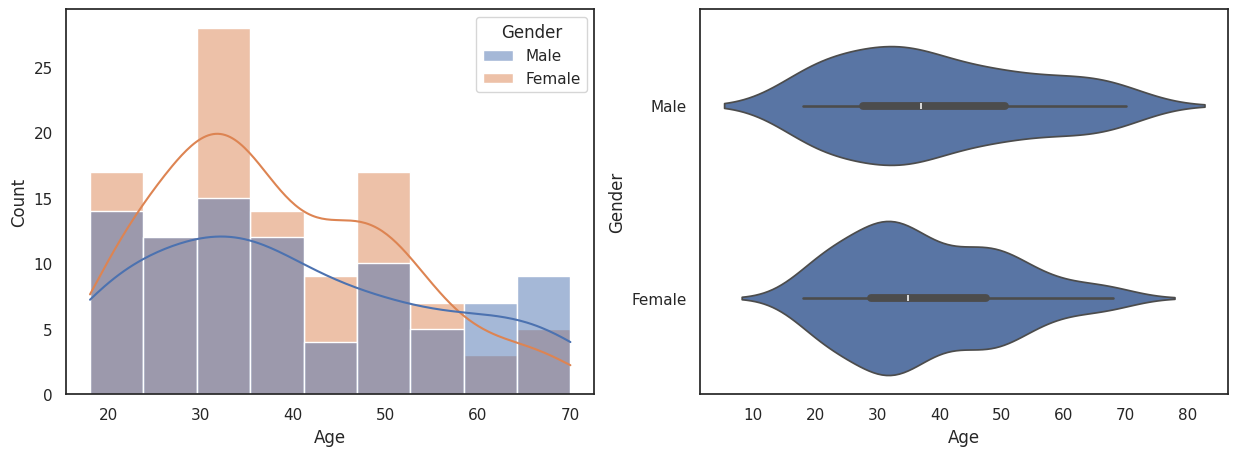

In [18]:
import seaborn as sns
plt.figure(figsize=(15, 5))
sns.set_theme(style="white")
plt.subplot(1,2,1)
sns.histplot(x='Age',data=data2,hue='Gender',kde=True);
plt.subplot(1,2,2)
sns.violinplot(x='Age',y='Gender',data=data2);

# Q8.data2 데이터프레임의 연속형 변수들 간의 모든 쌍별 관계를 시각화하는 서브플롯 그리드를 생성하시오.   
다음 조건을 반드시 만족해야 합니다.
1. 'Gender' 변수의 값에 따라 다른 색상으로 구분하여 표시되도록 할 것
2. 그래프의 대각선 아래쪽 (하삼각) 부분만 표시하여 중복되는 정보를 생략해 시각화할 것


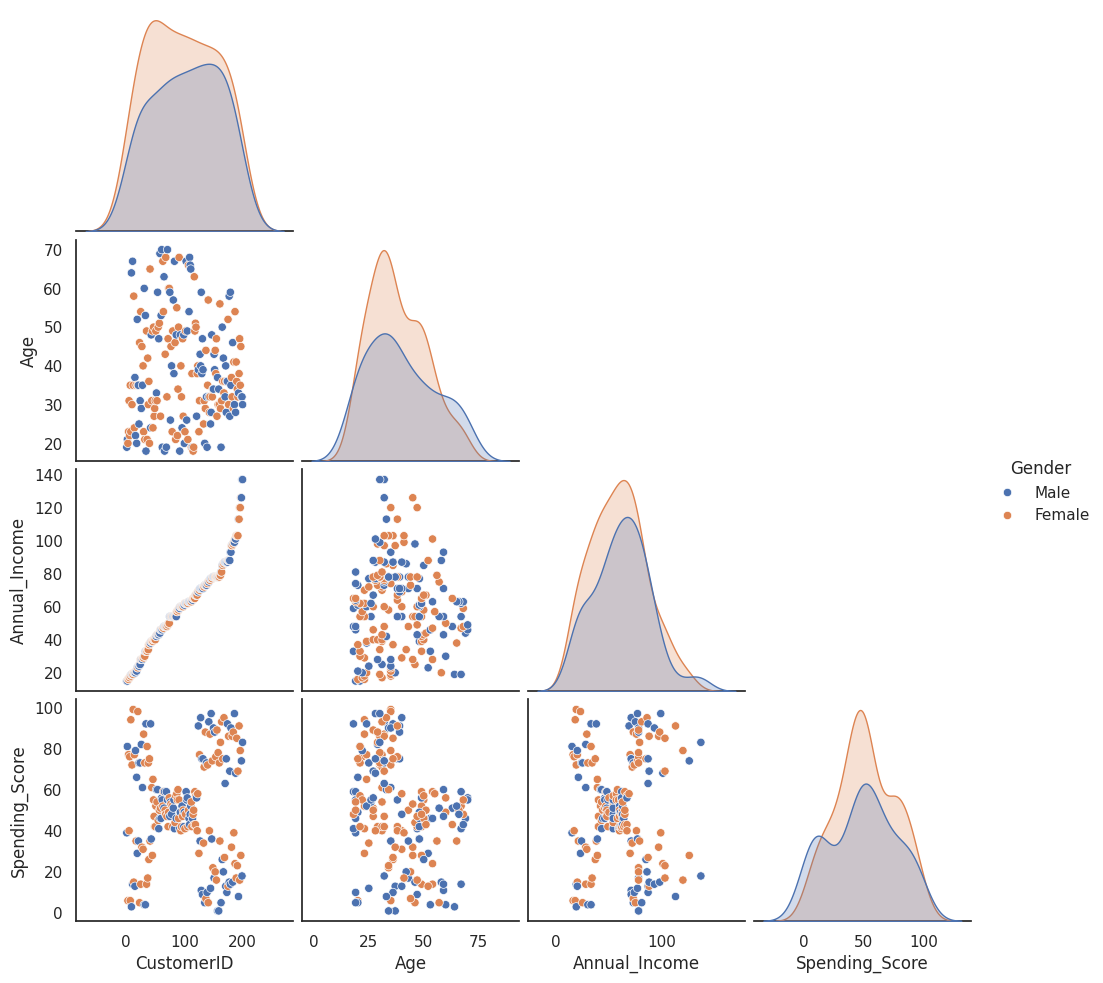

In [19]:
sns.pairplot(data2, hue="Gender", corner=True);

# Q9. Boxplot과 Stripplot을 활용한 성별 소득 분포 시각화
data2라는 이름으로 불러온 데이터프레임에는 두 개의 주요 변수 Gender (성별)와 Annual_Income (연간 수입)이 포함되어 있다.

다음 조건에 따라 시각화를 수행하시오:
- 성별(Gender)에 따른 연간 수입(Annual_Income) 분포를 시각화하시오.
- Boxplot과 Stripplot을 겹쳐서 함께 사용하시오
- boxplot에는 다음 조건을 만족시켜야 한다:
    - x축은 성별(Gender), y축은 연간 수입(Annual_Income)
    - 성별을 기준으로 색상을 나누고, 팔레트는 pastel을 사용하시오
- stripplot에는 다음 조건을 추가하시오:
    - 점의 색상은 회색(gray), 모양은 사각형(s)
    - 데이터가 겹치지 않도록 지터를 사용하시오
    - 투명도는 0.5로 설정할 것
- 전체 시각화의 제목은 "Annual Income by Gender with Stripplot" 으로 설정하시오.
- 시각화를 출력하시오.

[]

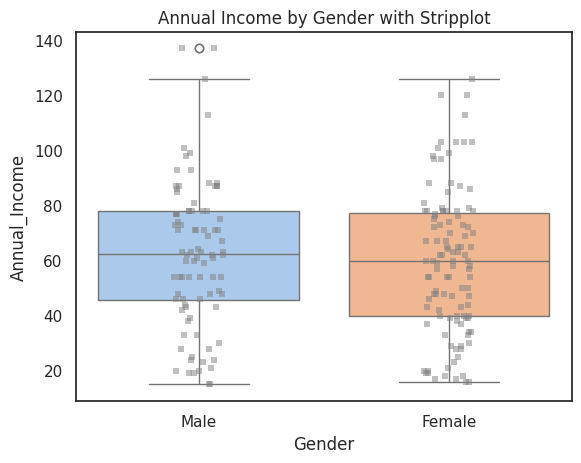

In [20]:
sns.boxplot(x='Gender', y='Annual_Income', data=data2,hue='Gender',palette='pastel');
sns.stripplot(x='Gender', y='Annual_Income',data=data2,color='gray',marker='s', jitter=True, alpha=0.5);
plt.title("Annual Income by Gender with Stripplot")
plt.plot()